# Targeted Statistical Analysis (second version)

This notebook is a trimmed second version of the SA statistics workflow. It implements the revised specification:

- outcome: logit-transformed `share_of_correct_agents_at_convergence` with the finite-sample offset `(p * (N - 1) + 0.5) / N`
- per-cell models: one model per `(source network x targeted SA statistic)`
- predictors: only the deliberately targeted achieved statistic plus `n_experiments` and `uncertainty`
- scaling: predictors are standardized once on the combined dataset before splitting into cells
- uncertainty: cluster-robust SEs by SA output network when a cluster identifier is available, otherwise HC3
- outputs: one forest plot for the nine targeted slopes, inverse-variance pooled summaries, and standardized-scale partial-residual diagnostics


## Data Prep

The old near-constant predictor screening is not needed here because each cell only includes the targeted SA statistic and the two simulation controls.

In [7]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path

plt.style.use("opinionated_rc")
font_dir = Path.home() / "Downloads" / "Source_Sans_3" / "static"

source_sans_3_paths = [
    font_dir / "SourceSans3-Regular.ttf",
    font_dir / "SourceSans3-Bold.ttf",
    font_dir / "SourceSans3-Italic.ttf",
    font_dir / "SourceSans3-BoldItalic.ttf",
]

missing = [path for path in source_sans_3_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing Source Sans 3 font files: "
        + ", ".join(str(path) for path in missing)
    )

for font_path in source_sans_3_paths:
    font_manager.fontManager.addfont(str(font_path))

plt.rcParams["font.family"] = ["Source Sans 3"]
plt.rcParams["font.sans-serif"] = [
    "Source Sans 3",
    *plt.rcParams.get("font.sans-serif", []),
]



In [8]:
from pathlib import Path
import json

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

try:
    import colormaps
except Exception:
    colormaps = None

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# try:
#     plt.style.use("opinionated_rc")
# except OSError:
#     pass



sa_results_dir = Path("results/SA_approach_run_v6_1k_steps") # v5 



figures_dir = Path("Figures") / "targeted_stats_v2"
figures_dir.mkdir(parents=True, exist_ok=True)

HIGH_RES_PNG_DPI = 600


def save_figure_with_png(fig, path, *, dpi=300, png_dpi=HIGH_RES_PNG_DPI, **savefig_kwargs):
    path = Path(path)
    png_path = path.with_suffix(".png")
    fig.savefig(path, dpi=dpi, **savefig_kwargs)
    fig.savefig(png_path, dpi=png_dpi, **savefig_kwargs)
    return {"pdf": path, "png": png_path}

cmap_config_path = Path("utils") / "network_colormaps.json"
with cmap_config_path.open("r", encoding="utf-8") as f:
    cmap_config = json.load(f)

colormap_fallbacks = {
    name: plt.get_cmap(fallback_name)
    for name, fallback_name in cmap_config.get("fallbacks", {}).items()
}
network_colormap_names = dict(cmap_config.get("network_colormaps", {}))
network_source_key_aliases = {
    "pud_network": "pud",
    "pud": "pud",
    "tobacco_network": "tobacco",
    "tobacco": "tobacco",
    "ego_network": "ego_depletion",
    "ego_depletion_network": "ego_depletion",
    "ego_depletion": "ego_depletion",
}
network_display_labels = {
    "pud": "Peptic Ulcer",
    "tobacco": "Tobacco",
    "ego_depletion": "Ego Depletion",
}
network_color_value = 0.0


def source_key(source_id):
    source = str(source_id).lower()
    if source in network_source_key_aliases:
        return network_source_key_aliases[source]
    if "tobacco" in source:
        return "tobacco"
    if "ego" in source:
        return "ego_depletion"
    if "pud" in source or "peptic" in source:
        return "pud"
    return source


def resolve_colormap(name):
    if colormaps is not None:
        if hasattr(colormaps, name):
            return getattr(colormaps, name)
        if name.endswith("_r") and hasattr(colormaps, name[:-2]):
            return getattr(colormaps, name[:-2]).reversed()
    if name in colormap_fallbacks:
        return colormap_fallbacks[name]
    if name.endswith("_r") and name[:-2] in colormap_fallbacks:
        return colormap_fallbacks[name[:-2]].reversed()
    try:
        return plt.get_cmap(name)
    except ValueError:
        return plt.cm.viridis


def source_color(source_id, value=network_color_value):
    key = source_key(source_id)
    cmap_name = network_colormap_names.get(key, cmap_config.get("default", "viridis"))
    cmap = resolve_colormap(cmap_name)
    return mcolors.to_hex(cmap(value))


raw_target = "share_of_correct_agents_at_convergence"
logit_target = "share_correct_logit"
adjusted_target = "share_correct_adjusted"
agent_count_col = "n_agents"

target_stat_order = ["density", "degree_gini", "clustering"]
target_predictor_map = {
    "density": "sa_achieved_density",
    "degree_gini": "sa_achieved_degree_gini",
    "clustering": "sa_achieved_clustering",
}
control_predictors = ["n_experiments", "uncertainty"]
targeted_predictors = [target_predictor_map[name] for name in target_stat_order]
standardized_predictors = control_predictors + targeted_predictors + ["sa_edit_distance_fraction"]

cluster_candidates = [
    "sa_saved_graph_path",
    "sa_matrix_path",
    "network_path",
    "sa_run_id",
    "sa_seed",
    "sa_grid_index",
]

label_map = {
    "density": "Density",
    "degree_gini": "Degree gini",
    "clustering": "Clustering",
    "n_experiments": "Number of experiments",
    "uncertainty": "Problem uncertainty",
    "sa_achieved_density": "Achieved density",
    "sa_achieved_degree_gini": "Achieved degree gini",
    "sa_achieved_clustering": "Achieved clustering",
    "sa_edit_distance_fraction": "SA edit distance / baseline edges",
    raw_target: "Share correct agents",
    logit_target: "Logit share correct agents",
}


def format_p(p_value):
    if pd.isna(p_value):
        return "= NA"
    if p_value < 0.001:
        return "< .001"
    return f"= {p_value:.3f}".replace("0.", ".")


def safe_filename(value):
    return "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in str(value))


def source_label(source_id):
    key = source_key(source_id)
    return network_display_labels.get(
        key,
        str(source_id).replace("_network", "").replace("_", " ").title(),
    )


def target_sort_key(target_stat):
    try:
        return target_stat_order.index(str(target_stat))
    except ValueError:
        return len(target_stat_order)


def numeric_or_nan(df, column):
    if column not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype=float)
    return pd.to_numeric(df[column], errors="coerce")


def logit_adjusted_share(p, n_agents):
    p = pd.to_numeric(p, errors="coerce").clip(0, 1)
    n = pd.to_numeric(n_agents, errors="coerce")
    finite_n = n[np.isfinite(n) & (n > 1)]
    fallback_n = float(finite_n.median()) if not finite_n.empty else 100.0
    n = n.where(np.isfinite(n) & (n > 1), fallback_n)

    adjusted = (p * (n - 1) + 0.5) / n
    adjusted = adjusted.clip(1e-9, 1 - 1e-9)
    return adjusted, np.log(adjusted / (1 - adjusted))


def prepare_sa_results(df, path):
    out = df.copy()

    if "sa_source_id" in out.columns:
        source = out["sa_source_id"]
    elif "source_id" in out.columns:
        source = out["source_id"]
    else:
        source = pd.Series(path.stem, index=out.index)

    out["analysis_source_id"] = source.fillna(path.stem).astype(str)
    out["analysis_source_file"] = path.name
    out["sa_target_stat"] = out["sa_target_stat"].astype(str)

    out[raw_target] = numeric_or_nan(out, raw_target)
    out[agent_count_col] = numeric_or_nan(out, agent_count_col)

    out["sa_edit_distance"] = numeric_or_nan(out, "sa_edit_distance")
    baseline_edges = numeric_or_nan(out, "sa_m0").replace(0, np.nan)
    out["sa_edit_distance_fraction"] = out["sa_edit_distance"] / baseline_edges

    for column in control_predictors + targeted_predictors:
        out[column] = numeric_or_nan(out, column)

    out[adjusted_target], out[logit_target] = logit_adjusted_share(out[raw_target], out[agent_count_col])
    return out


def add_global_z_scores(df, columns):
    out = df.copy()
    rows = []
    for column in columns:
        values = pd.to_numeric(out[column], errors="coerce")
        mean = values.mean()
        sd = values.std(ddof=1)
        z_column = f"z_{column}"
        if pd.notna(sd) and sd > 0:
            out[z_column] = (values - mean) / sd
        else:
            out[z_column] = np.nan
        rows.append({"predictor": column, "mean": mean, "sd": sd, "z_column": z_column})
    return out, pd.DataFrame(rows)


csv_paths = sorted(sa_results_dir.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No SA result CSVs found in {sa_results_dir.resolve()}")

combined_results_df = pd.concat(
    [prepare_sa_results(pd.read_csv(path), path) for path in csv_paths],
    ignore_index=True,
)
combined_results_df, global_standardization_df = add_global_z_scores(
    combined_results_df,
    standardized_predictors,
)

source_groups = (
    combined_results_df.groupby("analysis_source_id", dropna=False)
    .agg(
        n_rows=(raw_target, "size"),
        n_complete_outcomes=(raw_target, "count"),
        mean_share_correct=(raw_target, "mean"),
        share_at_ceiling=(raw_target, lambda x: np.isclose(pd.to_numeric(x, errors="coerce"), 1.0).mean()),
        share_at_floor=(raw_target, lambda x: np.isclose(pd.to_numeric(x, errors="coerce"), 0.0).mean()),
        mean_logit_share=(logit_target, "mean"),
    )
    .reset_index()
)

analysis_groups = (
    combined_results_df.groupby(["analysis_source_id", "sa_target_stat"], dropna=False)
    .agg(
        n_rows=(raw_target, "size"),
        n_complete_outcomes=(raw_target, "count"),
        mean_share_correct=(raw_target, "mean"),
        share_at_ceiling=(raw_target, lambda x: np.isclose(pd.to_numeric(x, errors="coerce"), 1.0).mean()),
        mean_logit_share=(logit_target, "mean"),
        n_sa_networks=("sa_saved_graph_path", "nunique"),
    )
    .reset_index()
    .sort_values(["analysis_source_id", "sa_target_stat"], key=lambda s: s.map(target_sort_key) if s.name == "sa_target_stat" else s)
)

print(f"Loaded {len(csv_paths)} SA result file(s) from {sa_results_dir}")
print(f"Loaded {len(combined_results_df):,} rows")
print(f"Figures and summary tables will be written to {figures_dir}")

print("Network colors from colormap scale value", network_color_value)
for source_id in sorted(combined_results_df["analysis_source_id"].dropna().astype(str).unique()):
    print(f"  {source_label(source_id)}: {source_color(source_id)}")

display(source_groups)
print("Source x targeted-stat composition:")
display(analysis_groups)
print("Global predictor standardization parameters:")
display(global_standardization_df)


Loaded 3 SA result file(s) from results/SA_approach_run_v6_1k_steps
Loaded 30,000 rows
Figures and summary tables will be written to Figures/targeted_stats_v2
Network colors from colormap scale value 0.0
  Ego Depletion: #2b075c
  Peptic Ulcer: #ee4d5a
  Tobacco: #2a5674


,analysis_source_id,n_rows,n_complete_outcomes,mean_share_correct,share_at_ceiling,share_at_floor,mean_logit_share
0,ego_network,10000,10000,0.923739,0.1564,0.0,4.051004
1,pud_network,10000,10000,0.706441,0.0000,0.0,0.940547
2,tobacco_network,10000,10000,0.819961,0.0000,0.0,1.643524


Source x targeted-stat composition:


,analysis_source_id,sa_target_stat,n_rows,n_complete_outcomes,mean_share_correct,share_at_ceiling,mean_logit_share,n_sa_networks
2,ego_network,density,3934,3934,0.917741,0.161668,3.944645,100
1,ego_network,degree_gini,3537,3537,0.926563,0.146735,4.032092,95
0,ego_network,clustering,2529,2529,0.929120,0.161724,4.242900,68
5,pud_network,density,2718,2718,0.719610,0.000000,1.015251,72
4,pud_network,degree_gini,3444,3444,0.702942,0.000000,0.919164,89
3,pud_network,clustering,3838,3838,0.700255,0.000000,0.906831,100
8,tobacco_network,density,3383,3383,0.823579,0.000000,1.719226,99
7,tobacco_network,degree_gini,3060,3060,0.819785,0.000000,1.617554,90
6,tobacco_network,clustering,3557,3557,0.816671,0.000000,1.593867,100


Global predictor standardization parameters:


,predictor,mean,sd,z_column
0,n_experiments,5484.715400,2591.292435,z_n_experiments
1,uncertainty,0.000500,0.000287,z_uncertainty
2,sa_achieved_density,0.015816,0.005153,z_sa_achieved_density
3,sa_achieved_degree_gini,0.740974,0.156568,z_sa_achieved_degree_gini
4,sa_achieved_clustering,0.354864,0.094964,z_sa_achieved_clustering
5,sa_edit_distance_fraction,0.286755,0.236865,z_sa_edit_distance_fraction


In [9]:
list(
    combined_results_df.columns)

['randomized',
 'unique_id',
 'network_type',
 'source_id',
 'network_path',
 'uncertainty',
 'n_experiments',
 'parameter_random_seed',
 'sa_source_id',
 'sa_source_path',
 'sa_n',
 'sa_m0',
 'sa_target_stat',
 'sa_target_value_requested',
 'sa_seed',
 'sa_degree_gini_mode',
 'sa_connectivity_mode',
 'sa_in_band_loss_mode',
 'sa_target_in_band_loss_mode',
 'sa_preserve_in_band_loss_mode',
 'sa_feasible_preserve_weight',
 'sa_feasible_selection_mode',
 'sa_baseline_density',
 'sa_baseline_degree_gini',
 'sa_baseline_clustering',
 'sa_baseline_triplets',
 'sa_baseline_closed_triplets',
 'sa_target_value_achieved',
 'sa_achieved_density',
 'sa_achieved_degree_gini',
 'sa_achieved_clustering',
 'sa_achieved_triplets',
 'sa_achieved_closed_triplets',
 'sa_target_error',
 'sa_target_error_scaled',
 'sa_preserve_center',
 'sa_max_preserve_error_scaled',
 'sa_edit_distance',
 'sa_feasible',
 'sa_delta_density',
 'sa_delta_degree_gini',
 'sa_delta_clustering',
 'sa_preserve_error_degree_gini',

## Per-Cell Models

Each model estimates the slope for the statistic that was deliberately varied in that cell. The two non-network controls remain in the formula. SEs are clustered by the repeated SA-output network identifier when available.

In [10]:
def choose_cluster_column(data):
    for column in cluster_candidates:
        if column not in data.columns:
            continue
        groups = data[column].dropna()
        n_groups = int(groups.nunique())
        if 2 <= n_groups < len(data):
            return column, n_groups
    return None, 0


def fit_targeted_model(df, source_id, target_stat, extra_controls=None):
    
    print("source_id", source_id)
    print("target_stat", target_stat)
    
    extra_controls = list(extra_controls or [])
    if target_stat not in target_predictor_map:
        raise ValueError(f"No targeted predictor configured for target stat {target_stat!r}")

    targeted_predictor = target_predictor_map[target_stat]
    
    raw_predictors = [targeted_predictor, *control_predictors, *extra_controls]
    z_predictors = [f"z_{predictor}" for predictor in raw_predictors]
    model_columns = [logit_target, *z_predictors]
    
    print("model_columns", model_columns)


    available_cluster_columns = [column for column in cluster_candidates if column in df.columns]
    complete = df.dropna(subset=model_columns).copy()
    if len(complete) <= len(z_predictors) + 1:
        raise ValueError("not enough complete rows for OLS")

    formula = f"{logit_target} ~ " + " + ".join(z_predictors)
    ols = smf.ols(formula, data=complete)

    cluster_column, n_clusters = choose_cluster_column(complete)
    if cluster_column is None:
        model = ols.fit(cov_type="HC3")
        cov_type = "HC3"
        n_clusters = np.nan
    else:
        model = ols.fit(cov_type="cluster", cov_kwds={"groups": complete[cluster_column]})
        cov_type = f"cluster({cluster_column})"

    print( model.summary())
    targeted_z = f"z_{targeted_predictor}"
    conf_low, conf_high = model.conf_int().loc[targeted_z]
    row = {
        "source_id": source_id,
        "source_label": source_label(source_id),
        "target_stat": target_stat,
        "target_label": label_map.get(target_stat, target_stat),
        "targeted_predictor": targeted_predictor,
        "targeted_z": targeted_z,
        "formula": formula,
        "n_obs": int(model.nobs),
        "cluster_column": cluster_column,
        "n_clusters": n_clusters,
        "cov_type": cov_type,
        "coef": model.params[targeted_z],
        "se": model.bse[targeted_z],
        "ci_low": conf_low,
        "ci_high": conf_high,
        "p_value": model.pvalues[targeted_z],
        "r_squared": model.rsquared,
        "extra_controls": ", ".join(extra_controls),
    }
    print("\n")
    return model, complete, row


models = {}
model_data = {}
coef_rows = []

for (source_id, target_stat), group in sorted(
    combined_results_df.groupby(["analysis_source_id", "sa_target_stat"], dropna=False),
    key=lambda item: (str(item[0][0]), target_sort_key(item[0][1]), str(item[0][1])),
):
    source_id = str(source_id)
    target_stat = str(target_stat)
    name = f"{source_id} | {target_stat}"
    try:
        model, complete, row = fit_targeted_model(group, source_id, target_stat)
    except ValueError as exc:
        print(f"Skipping {name}: {exc}")
        continue
    models[name] = model
    model_data[name] = complete
    coef_rows.append(row)

coef_df = pd.DataFrame(coef_rows).sort_values(
    ["target_stat", "source_id"],
    key=lambda s: s.map(target_sort_key) if s.name == "target_stat" else s,
).reset_index(drop=True)


summary_path = figures_dir / "targeted_stat_slopes.csv"
coef_df.to_csv(summary_path, index=False)

display_columns = [
    "source_id",
    "target_stat",
    "targeted_predictor",
    "coef",
    "se",
    "ci_low",
    "ci_high",
    "p_value",
    "n_obs",
    "n_clusters",
    "cov_type",
    "r_squared",
]

display(coef_df[display_columns])
print(f"Saved coefficient table to {summary_path}")


source_id ego_network
target_stat density
model_columns ['share_correct_logit', 'z_sa_achieved_density', 'z_n_experiments', 'z_uncertainty']
                             OLS Regression Results                            
Dep. Variable:     share_correct_logit   R-squared:                       0.639
Model:                             OLS   Adj. R-squared:                  0.639
Method:                  Least Squares   F-statistic:                     1130.
Date:                 Mon, 04 May 2026   Prob (F-statistic):           2.06e-76
Time:                         15:09:15   Log-Likelihood:                -6569.9
No. Observations:                 3934   AIC:                         1.315e+04
Df Residuals:                     3930   BIC:                         1.317e+04
Df Model:                            3                                         
Covariance Type:               cluster                                         
                            coef    std err          z     

                             OLS Regression Results                            
Dep. Variable:     share_correct_logit   R-squared:                       0.757
Model:                             OLS   Adj. R-squared:                  0.757
Method:                  Least Squares   F-statistic:                     2873.
Date:                 Mon, 04 May 2026   Prob (F-statistic):           2.77e-92
Time:                         15:09:15   Log-Likelihood:                -5014.4
No. Observations:                 3537   AIC:                         1.004e+04
Df Residuals:                     3533   BIC:                         1.006e+04
Df Model:                            3                                         
Covariance Type:               cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   

,source_id,target_stat,targeted_predictor,coef,se,ci_low,ci_high,p_value,n_obs,n_clusters,cov_type,r_squared
0,ego_network,density,sa_achieved_density,0.799205,0.045553,0.709923,0.888487,6.544983e-69,3934,100,cluster(sa_saved_graph_path),0.639177
1,pud_network,density,sa_achieved_density,0.146172,0.008529,0.129455,0.162888,7.667749e-66,2718,72,cluster(sa_saved_graph_path),0.335483
2,tobacco_network,density,sa_achieved_density,0.348274,0.006298,0.335930,0.360618,0.000000e+00,3383,99,cluster(sa_saved_graph_path),0.667735
3,ego_network,degree_gini,sa_achieved_degree_gini,0.130327,0.018076,0.094899,0.165755,5.596842e-13,3537,95,cluster(sa_saved_graph_path),0.757465
4,pud_network,degree_gini,sa_achieved_degree_gini,0.029875,0.010193,0.009897,0.049853,3.379571e-03,3444,89,cluster(sa_saved_graph_path),0.301564
5,tobacco_network,degree_gini,sa_achieved_degree_gini,0.048139,0.006366,0.035662,0.060615,3.959977e-14,3060,90,cluster(sa_saved_graph_path),0.591256
6,ego_network,clustering,sa_achieved_clustering,-0.015616,0.018169,-0.051227,0.019996,3.900938e-01,2529,68,cluster(sa_saved_graph_path),0.667745
7,pud_network,clustering,sa_achieved_clustering,-0.041362,0.005114,-0.051386,-0.031338,6.089814e-16,3838,100,cluster(sa_saved_graph_path),0.294432
8,tobacco_network,clustering,sa_achieved_clustering,-0.059683,0.006222,-0.071878,-0.047489,8.598588e-22,3557,100,cluster(sa_saved_graph_path),0.549504


Saved coefficient table to Figures/targeted_stats_v2/targeted_stat_slopes.csv


## Forest Plot: Nine Targeted Slopes

The x-axis is the logit-scale change in share-correct for a one global-SD increase in the targeted achieved network statistic, controlling for `n_experiments` and `uncertainty`.

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

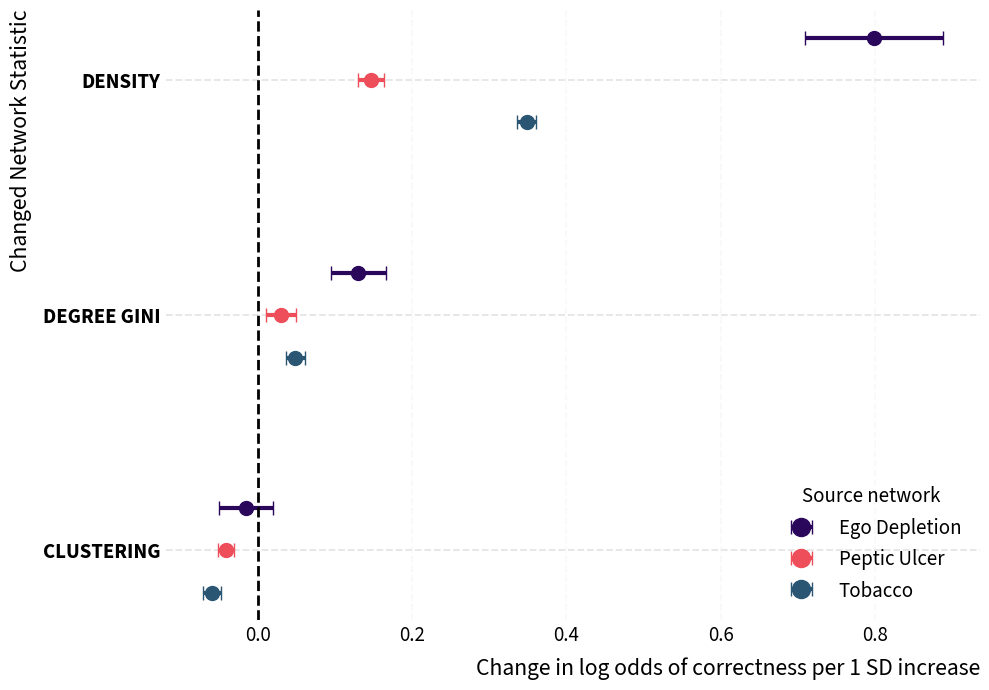

Saved forest plot to {'pdf': PosixPath('Figures/targeted_stats_v2/targeted_stat_forest_plot.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/targeted_stat_forest_plot.png')}


In [24]:
source_order = sorted(coef_df["source_id"].unique())
source_colors = {source_id: source_color(source_id) for source_id in source_order}
y_base = {target_stat: idx for idx, target_stat in enumerate(target_stat_order)}
offsets = dict(zip(source_order, np.linspace(-0.18, 0.18, len(source_order))))

fig, ax = plt.subplots(figsize=(10,7))

for source_id in source_order:
    subset = coef_df[coef_df["source_id"] == source_id]
    y = [y_base[target_stat] + offsets[source_id] for target_stat in subset["target_stat"]]
    x = subset["coef"].to_numpy()
    xerr = np.vstack([
        x - subset["ci_low"].to_numpy(),
        subset["ci_high"].to_numpy() - x,
    ])
    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="o",
        color=source_colors[source_id],
        ecolor=source_colors[source_id],
        elinewidth=3,          # <-- thicker errorbar line
        capsize=5,             # <-- slightly bigger caps
        markersize=10,         # <-- bigger dots
        label=source_label(source_id),
    )

ax.axvline(0, color="black", linestyle="--", linewidth=2)   # <-- thicker vertical reference line
ax.set_yticks([y_base[target_stat] for target_stat in target_stat_order])
ax.set_yticklabels(
    [label_map.get(target_stat, target_stat).upper() for target_stat in target_stat_order],
    fontweight="bold"
)
ax.invert_yaxis()
ax.set_xlabel("Change in log odds of correctness per 1 SD increase",fontweight="regular")
ax.set_ylabel("Changed Network Statistic",fontweight="regular")

legend = ax.legend(title="Source network", frameon=False, loc="best")
plt.setp(legend.get_texts())#, fontweight="bold")
plt.setp(legend.get_title())#, fontweight="bold")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
forest_path = figures_dir / "targeted_stat_forest_plot.pdf"
forest_paths = save_figure_with_png(fig, forest_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved forest plot to {forest_paths}")


## Inverse-Variance Pooled Slopes

This fixed-effect summary pools the three source-specific slopes for each targeted statistic using inverse-variance weights from the per-cell SEs. It gives one headline logit-scale estimate per network statistic while preserving the source-specific estimates above.

,target_stat,pooled_coef,pooled_se,ci_low,ci_high,p_value,n_sources,q,i2
0,density,0.283338,0.005035,0.273469,0.293207,0.0,3.0,493.201270,0.995945
1,degree_gini,0.050166,0.005173,0.040026,0.060306,0.0,3.0,23.730369,0.915720
2,clustering,-0.047253,0.003861,-0.054820,-0.039687,0.0,3.0,8.350354,0.760489


Saved pooled table to Figures/targeted_stats_v2/targeted_stat_pooled_slopes.csv


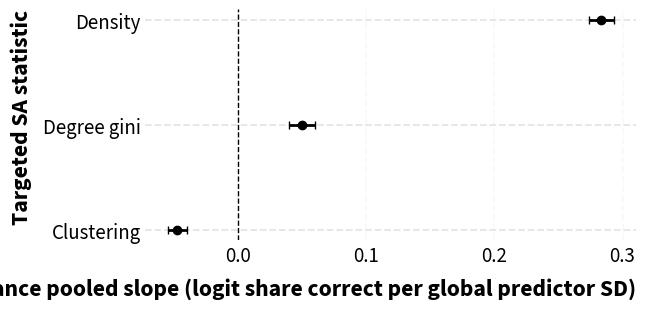

Saved pooled forest plot to {'pdf': PosixPath('Figures/targeted_stats_v2/targeted_stat_pooled_forest_plot.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/targeted_stat_pooled_forest_plot.png')}


In [15]:
def inverse_variance_pool(group):
    valid = group[np.isfinite(group["coef"]) & np.isfinite(group["se"]) & (group["se"] > 0)].copy()
    if valid.empty:
        return pd.Series({
            "pooled_coef": np.nan,
            "pooled_se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p_value": np.nan,
            "n_sources": 0,
            "q": np.nan,
            "i2": np.nan,
        })

    weights = 1 / np.square(valid["se"].to_numpy())
    coefs = valid["coef"].to_numpy()
    pooled_coef = np.sum(weights * coefs) / np.sum(weights)
    pooled_se = np.sqrt(1 / np.sum(weights))
    ci_low = pooled_coef - 1.96 * pooled_se
    ci_high = pooled_coef + 1.96 * pooled_se
    z_value = pooled_coef / pooled_se if pooled_se > 0 else np.nan
    p_value = 2 * (1 - scipy_norm_cdf(abs(z_value))) if np.isfinite(z_value) else np.nan

    q = float(np.sum(weights * np.square(coefs - pooled_coef)))
    df_q = max(len(valid) - 1, 1)
    i2 = max(0.0, (q - df_q) / q) if q > 0 else 0.0
    return pd.Series({
        "pooled_coef": pooled_coef,
        "pooled_se": pooled_se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value,
        "n_sources": len(valid),
        "q": q,
        "i2": i2,
    })


def scipy_norm_cdf(x):
    from scipy.stats import norm
    return norm.cdf(x)


pooled_df = (
    coef_df.groupby("target_stat", sort=False)
    .apply(inverse_variance_pool, include_groups=False)
    .reset_index()
)
pooled_df["target_label"] = pooled_df["target_stat"].map(lambda x: label_map.get(x, x))
pooled_df = pooled_df.sort_values("target_stat", key=lambda s: s.map(target_sort_key)).reset_index(drop=True)

pooled_path = figures_dir / "targeted_stat_pooled_slopes.csv"
pooled_df.to_csv(pooled_path, index=False)
display(pooled_df[["target_stat", "pooled_coef", "pooled_se", "ci_low", "ci_high", "p_value", "n_sources", "q", "i2"]])
print(f"Saved pooled table to {pooled_path}")

fig, ax = plt.subplots(figsize=(6.6, 3.2))
y = np.arange(len(pooled_df))
x = pooled_df["pooled_coef"].to_numpy()
xerr = np.vstack([
    x - pooled_df["ci_low"].to_numpy(),
    pooled_df["ci_high"].to_numpy() - x,
])
ax.errorbar(x, y, xerr=xerr, fmt="o", color="black", ecolor="black", elinewidth=2, capsize=3)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(pooled_df["target_label"])
ax.invert_yaxis()
ax.set_xlabel("Inverse-variance pooled slope (logit share correct per global predictor SD)")
ax.set_ylabel("Targeted SA statistic")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
pooled_plot_path = figures_dir / "targeted_stat_pooled_forest_plot.pdf"
pooled_plot_paths = save_figure_with_png(fig, pooled_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved pooled forest plot to {pooled_plot_paths}")


## Edit-Distance Control Sensitivity

The main model does not control for `sa_edit_distance_fraction`, matching the headline specification. This sensitivity adds it as a standardized covariate to check whether the targeted slopes are absorbing the dose of the SA intervention.

In [16]:
sensitivity_rows = []

for (source_id, target_stat), group in sorted(
    combined_results_df.groupby(["analysis_source_id", "sa_target_stat"], dropna=False),
    key=lambda item: (str(item[0][0]), target_sort_key(item[0][1]), str(item[0][1])),
):
    source_id = str(source_id)
    target_stat = str(target_stat)
    name = f"{source_id} | {target_stat}"
    try:
        _, _, row = fit_targeted_model(group, source_id, target_stat, extra_controls=["sa_edit_distance_fraction"])
    except ValueError as exc:
        print(f"Skipping sensitivity for {name}: {exc}")
        continue
    sensitivity_rows.append(row)

sensitivity_df = pd.DataFrame(sensitivity_rows)
comparison_df = coef_df.merge(
    sensitivity_df[["source_id", "target_stat", "coef", "se", "ci_low", "ci_high", "p_value", "n_obs", "n_clusters", "cov_type"]],
    on=["source_id", "target_stat"],
    suffixes=("_main", "_edit_distance_control"),
)
comparison_df["coef_shift"] = comparison_df["coef_edit_distance_control"] - comparison_df["coef_main"]

sensitivity_path = figures_dir / "targeted_stat_edit_distance_sensitivity.csv"
comparison_df.to_csv(sensitivity_path, index=False)

display(comparison_df[[
    "source_id",
    "target_stat",
    "coef_main",
    "se_main",
    "coef_edit_distance_control",
    "se_edit_distance_control",
    "coef_shift",
    "n_obs_main",
    "n_obs_edit_distance_control",
]])
print(f"Saved edit-distance sensitivity table to {sensitivity_path}")


source_id ego_network
target_stat density
model_columns ['share_correct_logit', 'z_sa_achieved_density', 'z_n_experiments', 'z_uncertainty', 'z_sa_edit_distance_fraction']
                             OLS Regression Results                            
Dep. Variable:     share_correct_logit   R-squared:                       0.652
Model:                             OLS   Adj. R-squared:                  0.652
Method:                  Least Squares   F-statistic:                     659.9
Date:                 Mon, 04 May 2026   Prob (F-statistic):           2.06e-70
Time:                         15:10:27   Log-Likelihood:                -6496.2
No. Observations:                 3934   AIC:                         1.300e+04
Df Residuals:                     3929   BIC:                         1.303e+04
Df Model:                            4                                         
Covariance Type:               cluster                                         
                            

                             OLS Regression Results                            
Dep. Variable:     share_correct_logit   R-squared:                       0.758
Model:                             OLS   Adj. R-squared:                  0.757
Method:                  Least Squares   F-statistic:                     2123.
Date:                 Mon, 04 May 2026   Prob (F-statistic):           3.33e-91
Time:                         15:10:27   Log-Likelihood:                -5013.4
No. Observations:                 3537   AIC:                         1.004e+04
Df Residuals:                     3532   BIC:                         1.007e+04
Df Model:                            4                                         
Covariance Type:               cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercep

,source_id,target_stat,coef_main,se_main,coef_edit_distance_control,se_edit_distance_control,coef_shift,n_obs_main,n_obs_edit_distance_control
0,ego_network,density,0.799205,0.045553,0.798422,0.029750,-0.000783,3934,3934
1,pud_network,density,0.146172,0.008529,0.137254,0.017562,-0.008917,2718,2718
2,tobacco_network,density,0.348274,0.006298,0.348301,0.006382,0.000026,3383,3383
3,ego_network,degree_gini,0.130327,0.018076,0.189676,0.048371,0.059349,3537,3537
4,pud_network,degree_gini,0.029875,0.010193,0.041436,0.013207,0.011561,3444,3444
5,tobacco_network,degree_gini,0.048139,0.006366,0.056000,0.006914,0.007862,3060,3060
6,ego_network,clustering,-0.015616,0.018169,-0.045367,0.031632,-0.029752,2529,2529
7,pud_network,clustering,-0.041362,0.005114,-0.042994,0.005673,-0.001632,3838,3838
8,tobacco_network,clustering,-0.059683,0.006222,-0.054062,0.006015,0.005622,3557,3557


Saved edit-distance sensitivity table to Figures/targeted_stats_v2/targeted_stat_edit_distance_sensitivity.csv


## Standardized Partial-Residual Diagnostics

These appendix plots use the same standardized predictor scale as the model. The annotated slope is therefore the visible logit-scale slope in the plot.

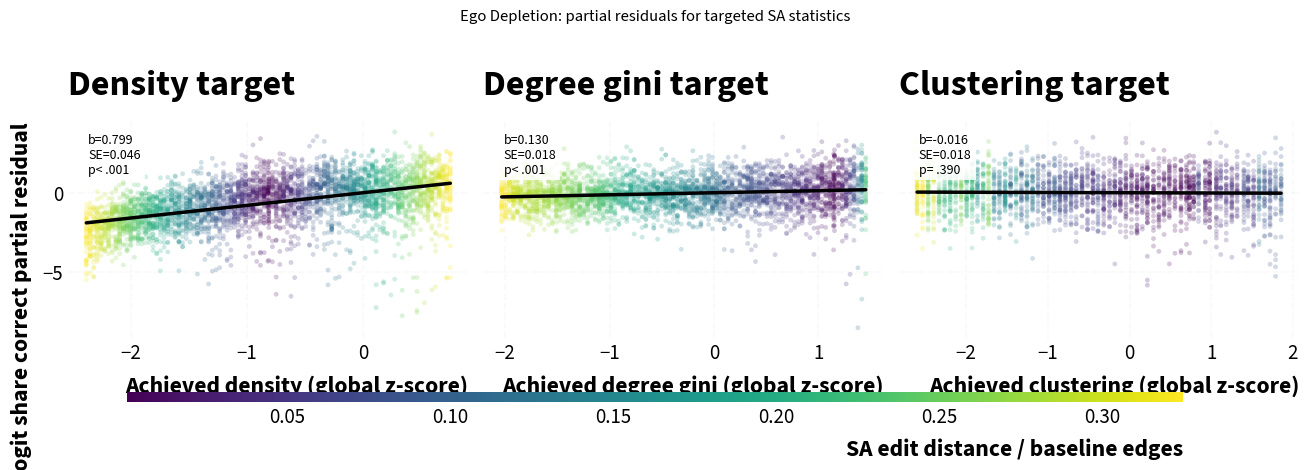

Saved partial-residual plot to {'pdf': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_ego_network.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_ego_network.png')}


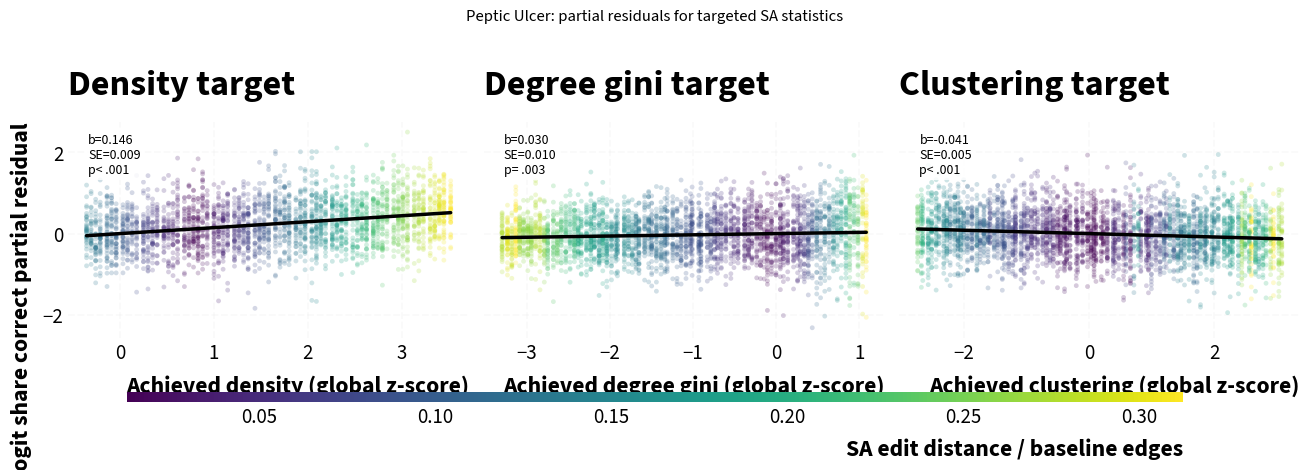

Saved partial-residual plot to {'pdf': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_pud_network.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_pud_network.png')}


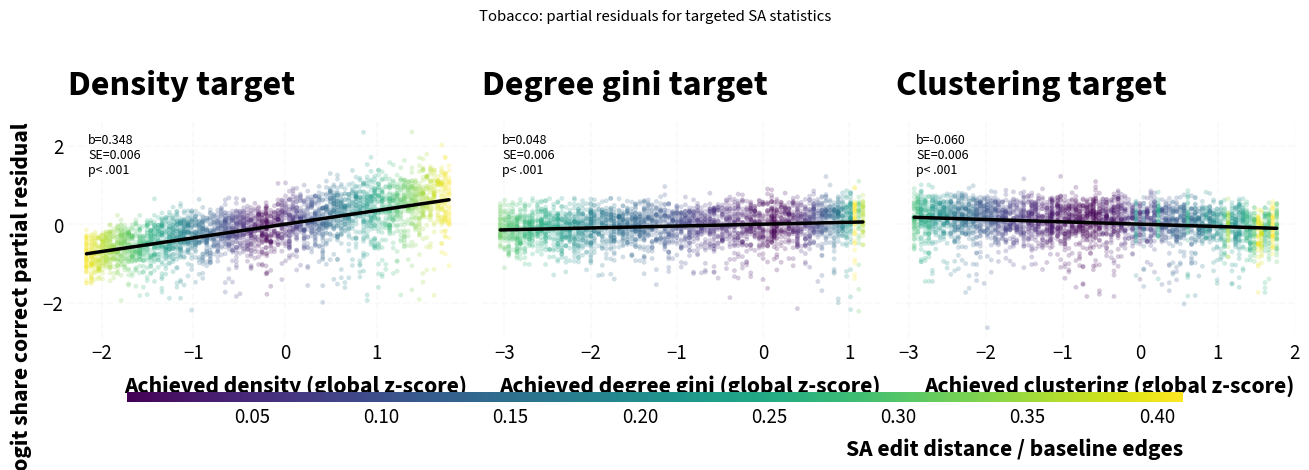

Saved partial-residual plot to {'pdf': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_tobacco_network.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/partial_residual_targeted_stats_tobacco_network.png')}


In [17]:
for source_id in sorted(coef_df["source_id"].unique()):
    facet_data = []
    for target_stat in target_stat_order:
        name = f"{source_id} | {target_stat}"
        if name not in models:
            continue
        model = models[name]
        data = model_data[name]
        row = coef_df[(coef_df["source_id"] == source_id) & (coef_df["target_stat"] == target_stat)].iloc[0]
        x_col = row["targeted_z"]
        x = data[x_col].to_numpy()
        y = model.resid.to_numpy() + model.params[x_col] * x
        color = data["sa_edit_distance_fraction"].to_numpy() if "sa_edit_distance_fraction" in data.columns else None

        facet_data.append({
            "target_stat": target_stat,
            "target_label": label_map.get(target_stat, target_stat),
            "x": x,
            "y": y,
            "color": color,
            "coef": model.params[x_col],
            "se": model.bse[x_col],
            "p_value": model.pvalues[x_col],
            "predictor_label": label_map.get(row["targeted_predictor"], row["targeted_predictor"]),
        })

    if not facet_data:
        continue

    fig, axes = plt.subplots(1, len(facet_data), figsize=(4.4 * len(facet_data), 4.0), sharey=True, squeeze=False)
    axes = axes.ravel()
    scatter = None
    y_all = np.concatenate([item["y"] for item in facet_data])
    y_pad = (y_all.max() - y_all.min()) * 0.05 if y_all.max() > y_all.min() else 1.0
    y_lim = (y_all.min() - y_pad, y_all.max() + y_pad)

    for ax, item in zip(axes, facet_data):
        if item["color"] is not None and np.isfinite(item["color"]).any():
            scatter = ax.scatter(item["x"], item["y"], c=item["color"], cmap="viridis", alpha=0.22, s=12, edgecolors="none")
        else:
            ax.scatter(item["x"], item["y"], alpha=0.35, s=12, edgecolors="none")

        x_line = np.linspace(np.nanmin(item["x"]), np.nanmax(item["x"]), 100)
        ax.plot(x_line, item["coef"] * x_line, color="black", linewidth=2.5)

        coef_text = f'b={item["coef"]:.3f}\nSE={item["se"]:.3f}\np{format_p(item["p_value"])}'
        ax.annotate(
            coef_text,
            xy=(0.05, 0.95),
            xycoords="axes fraction",
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="square", facecolor="white", alpha=0.85, edgecolor="none"),
        )
        ax.set_title(f'{item["target_label"]} target')
        ax.set_xlabel(f'{item["predictor_label"]} (global z-score)')
        ax.set_ylim(y_lim)
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Logit share correct partial residual")
    fig.suptitle(f"{source_label(source_id)}: partial residuals for targeted SA statistics", y=1.04)
    plt.tight_layout()

    if scatter is not None:
        fig.subplots_adjust(bottom=0.22)
        cbar_ax = fig.add_axes([0.10, 0.06, 0.80, 0.025])
        cbar = fig.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
        cbar.set_label(label_map["sa_edit_distance_fraction"])
        cbar.solids.set_alpha(1)

    partial_path = figures_dir / f"partial_residual_targeted_stats_{safe_filename(source_id)}.pdf"
    partial_paths = save_figure_with_png(fig, partial_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved partial-residual plot to {partial_paths}")


In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

try:
    display
except NameError:
    def display(obj):
        print(obj)


network_stat_cols = list(target_predictor_map.values())
predictor_to_stat = {value: key for key, value in target_predictor_map.items()}


def z_within_group(series):
    values = pd.to_numeric(series, errors="coerce")
    sd = values.std(ddof=1)
    if pd.notna(sd) and sd > 0:
        return (values - values.mean()) / sd
    return pd.Series(np.nan, index=series.index, dtype=float)


def add_cell_z_scores(df, columns):
    out = df.copy()
    group_cols = ["analysis_source_id", "sa_target_stat"]
    for column in columns:
        if column not in out.columns:
            continue
        out[f"cell_z_{column}"] = out.groupby(group_cols)[column].transform(z_within_group)
    return out


def choose_cluster_column_for_data(data):
    for column in cluster_candidates:
        if column not in data.columns:
            continue
        groups = data[column].dropna()
        n_groups = int(groups.nunique())
        if 2 <= n_groups < len(data):
            return column
    return None


def fit_cluster_or_hc3(formula, data):
    cluster_column = choose_cluster_column_for_data(data)

    if cluster_column is None:
        result = smf.ols(formula, data=data).fit(cov_type="HC3")
        return result, None, np.nan, "HC3"

    complete = data.dropna(subset=[cluster_column]).copy()
    n_clusters = int(complete[cluster_column].nunique())

    result = smf.ols(formula, data=complete).fit(
        cov_type="cluster",
        cov_kwds={"groups": complete[cluster_column]},
    )

    return result, cluster_column, n_clusters, f"cluster({cluster_column})"


def usable_predictors(data, predictors):
    usable = []
    for predictor in predictors:
        if predictor not in data.columns:
            continue

        values = pd.to_numeric(data[predictor], errors="coerce")
        if values.notna().sum() < 3:
            continue
        if values.nunique(dropna=True) < 2:
            continue
        if not np.isfinite(values.std(ddof=1)) or values.std(ddof=1) <= 0:
            continue

        usable.append(predictor)

    return usable


analysis_control_df = add_cell_z_scores(
    combined_results_df,
    network_stat_cols + control_predictors,
)


# ------------------------------------------------------------
# 1. Reference ranges: how much each statistic moves when it is
# directly targeted in each source network.
# ------------------------------------------------------------

reference_ranges = {}

for (source_id, target_stat), group in analysis_control_df.groupby(
    ["analysis_source_id", "sa_target_stat"],
    dropna=False,
):
    source_id = str(source_id)
    target_stat = str(target_stat)
    target_column = target_predictor_map.get(target_stat)

    if target_column is None:
        continue

    values = pd.to_numeric(group[target_column], errors="coerce").dropna()
    if values.empty:
        continue

    reference_ranges[(source_id, target_column)] = values.quantile(0.90) - values.quantile(0.10)


# ------------------------------------------------------------
# 2. Drift diagnostics.
# ------------------------------------------------------------

drift_rows = []

for (source_id, target_stat), group in analysis_control_df.groupby(
    ["analysis_source_id", "sa_target_stat"],
    dropna=False,
):
    source_id = str(source_id)
    target_stat = str(target_stat)
    target_column = target_predictor_map.get(target_stat)

    if target_column is None:
        continue

    target_z = f"cell_z_{target_column}"

    for other_column in network_stat_cols:
        if other_column == target_column:
            continue

        other_z = f"cell_z_{other_column}"
        complete = group.dropna(subset=[target_z, other_z]).copy()

        if len(complete) < 5:
            continue

        drift_model = smf.ols(f"{other_z} ~ {target_z}", data=complete).fit()

        other_values = pd.to_numeric(group[other_column], errors="coerce").dropna()
        if other_values.empty:
            side_range = np.nan
        else:
            side_range = other_values.quantile(0.90) - other_values.quantile(0.10)

        reference_range = reference_ranges.get((source_id, other_column), np.nan)

        if pd.notna(reference_range) and reference_range > 0:
            relative_side_range = side_range / reference_range
        else:
            relative_side_range = np.nan

        drift_rows.append({
            "source_id": source_id,
            "target_stat": target_stat,
            "targeted_predictor": target_column,
            "drifting_predictor": other_column,
            "drifting_stat": predictor_to_stat.get(other_column, other_column),
            "drift_slope_per_target_cell_sd": drift_model.params.get(target_z, np.nan),
            "drift_corr": complete[[target_z, other_z]].corr().iloc[0, 1],
            "side_range_10_to_90": side_range,
            "reference_range_when_it_is_targeted": reference_range,
            "relative_side_range": relative_side_range,
            "n_obs": len(complete),
        })


drift_diagnostics_df = pd.DataFrame(drift_rows).sort_values(
    ["source_id", "target_stat", "drifting_stat"],
    key=lambda s: s.map(target_sort_key) if s.name in ["target_stat", "drifting_stat"] else s,
).reset_index(drop=True)


# ------------------------------------------------------------
# 3. Direct-effect sensitivity model.
# This controls for the two non-target achieved network statistics.
# It estimates a more demanding estimand: the target effect holding
# the other achieved network statistics fixed.
# ------------------------------------------------------------

control_z = [f"cell_z_{column}" for column in control_predictors]
direct_rows = []

for (source_id, target_stat), group in analysis_control_df.groupby(
    ["analysis_source_id", "sa_target_stat"],
    dropna=False,
):
    source_id = str(source_id)
    target_stat = str(target_stat)
    target_column = target_predictor_map.get(target_stat)

    if target_column is None:
        continue

    target_z = f"cell_z_{target_column}"
    non_target_z = [
        f"cell_z_{column}"
        for column in network_stat_cols
        if column != target_column
    ]

    main_predictors = usable_predictors(group, [target_z] + control_z)
    adjusted_predictors = usable_predictors(group, [target_z] + control_z + non_target_z)

    if target_z not in main_predictors or target_z not in adjusted_predictors:
        continue

    main_data = group.dropna(subset=[logit_target] + main_predictors).copy()
    adjusted_data = group.dropna(subset=[logit_target] + adjusted_predictors).copy()

    if len(main_data) <= len(main_predictors) + 1:
        continue

    if len(adjusted_data) <= len(adjusted_predictors) + 1:
        continue

    main_formula = f"{logit_target} ~ " + " + ".join(main_predictors)
    adjusted_formula = f"{logit_target} ~ " + " + ".join(adjusted_predictors)

    main_result, _, main_n_clusters, main_cov_type = fit_cluster_or_hc3(main_formula, main_data)
    adjusted_result, _, adjusted_n_clusters, adjusted_cov_type = fit_cluster_or_hc3(adjusted_formula, adjusted_data)

    support_predictors = [predictor for predictor in adjusted_predictors if predictor != target_z]

    if support_predictors:
        support_data = adjusted_data.dropna(subset=[target_z] + support_predictors).copy()
        support_formula = f"{target_z} ~ " + " + ".join(support_predictors)
        support_result = smf.ols(support_formula, data=support_data).fit()
        target_residual_r2 = support_result.rsquared
        target_residual_sd = support_result.resid.std(ddof=1)
    else:
        target_residual_r2 = np.nan
        target_residual_sd = np.nan

    target_values = pd.to_numeric(adjusted_data[target_z], errors="coerce").dropna()

    if target_values.empty:
        target_z_10_to_90 = np.nan
    else:
        target_z_10_to_90 = target_values.quantile(0.90) - target_values.quantile(0.10)

    direct_rows.append({
        "source_id": source_id,
        "target_stat": target_stat,
        "targeted_predictor": target_column,
        "main_coef_cell_sd": main_result.params[target_z],
        "main_se": main_result.bse[target_z],
        "adjusted_coef_cell_sd": adjusted_result.params[target_z],
        "adjusted_se": adjusted_result.bse[target_z],
        "coef_shift": adjusted_result.params[target_z] - main_result.params[target_z],
        "main_effect_10_to_90_logit": main_result.params[target_z] * target_z_10_to_90,
        "adjusted_effect_10_to_90_logit": adjusted_result.params[target_z] * target_z_10_to_90,
        "target_residual_r2_given_controls_and_nontargets": target_residual_r2,
        "target_residual_sd_after_controls_and_nontargets": target_residual_sd,
        "n_obs_main": int(main_result.nobs),
        "n_obs_adjusted": int(adjusted_result.nobs),
        "n_clusters_main": main_n_clusters,
        "n_clusters_adjusted": adjusted_n_clusters,
        "cov_type_main": main_cov_type,
        "cov_type_adjusted": adjusted_cov_type,
        "main_formula": main_formula,
        "adjusted_formula": adjusted_formula,
    })


direct_sensitivity_df = pd.DataFrame(direct_rows).sort_values(
    ["source_id", "target_stat"],
    key=lambda s: s.map(target_sort_key) if s.name == "target_stat" else s,
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Save and display.
# ------------------------------------------------------------

drift_path = figures_dir / "network_stat_drift_diagnostics.csv"
direct_path = figures_dir / "direct_effect_nontarget_control_sensitivity.csv"

drift_diagnostics_df.to_csv(drift_path, index=False)
direct_sensitivity_df.to_csv(direct_path, index=False)

print(f"Saved drift diagnostics to {drift_path}")
print(f"Saved direct-effect sensitivity to {direct_path}")

print(
    "Drift diagnostics. Smaller relative_side_range values are more reassuring. "
    "Values near zero mean little drift. Values near one mean the non-target statistic "
    "moved about as much as it does when directly targeted."
)
display(drift_diagnostics_df)

print(
    "Direct-effect sensitivity. High target_residual_r2 means the adjusted direct effect "
    "is relying on little residual target variation after controlling for drift."
)
display(direct_sensitivity_df[[
    "source_id",
    "target_stat",
    "main_coef_cell_sd",
    "main_se",
    "adjusted_coef_cell_sd",
    "adjusted_se",
    "coef_shift",
    "main_effect_10_to_90_logit",
    "adjusted_effect_10_to_90_logit",
    "target_residual_r2_given_controls_and_nontargets",
    "target_residual_sd_after_controls_and_nontargets",
    "n_obs_main",
    "n_obs_adjusted",
]])

Saved drift diagnostics to Figures/targeted_stats_v2/network_stat_drift_diagnostics.csv
Saved direct-effect sensitivity to Figures/targeted_stats_v2/direct_effect_nontarget_control_sensitivity.csv
Drift diagnostics. Smaller relative_side_range values are more reassuring. Values near zero mean little drift. Values near one mean the non-target statistic moved about as much as it does when directly targeted.


,source_id,target_stat,targeted_predictor,drifting_predictor,drifting_stat,drift_slope_per_target_cell_sd,drift_corr,side_range_10_to_90,reference_range_when_it_is_targeted,relative_side_range,n_obs
0,ego_network,density,sa_achieved_density,sa_achieved_degree_gini,degree_gini,-5.806199e-01,-0.580620,0.000253,0.444826,0.000569,3934
1,ego_network,density,sa_achieved_density,sa_achieved_clustering,clustering,8.124437e-02,0.081244,0.000146,0.346422,0.000421,3934
2,ego_network,degree_gini,sa_achieved_degree_gini,sa_achieved_density,density,-1.517883e-18,NaN,0.000000,0.012847,0.000000,3537
3,ego_network,degree_gini,sa_achieved_degree_gini,sa_achieved_clustering,clustering,7.426452e-02,0.074265,0.000023,0.346422,0.000067,3537
4,ego_network,clustering,sa_achieved_clustering,sa_achieved_density,density,4.640385e-17,NaN,0.000000,0.012847,0.000000,2529
5,ego_network,clustering,sa_achieved_clustering,sa_achieved_degree_gini,degree_gini,-4.640385e-17,NaN,0.000000,0.444826,0.000000,2529
6,pud_network,density,sa_achieved_density,sa_achieved_degree_gini,degree_gini,7.017768e-02,0.070178,0.001552,0.559250,0.002774,2718
7,pud_network,density,sa_achieved_density,sa_achieved_clustering,clustering,1.722466e-01,0.172247,0.001081,0.441227,0.002449,2718
8,pud_network,degree_gini,sa_achieved_degree_gini,sa_achieved_clustering,clustering,5.005726e-02,0.050057,0.003482,0.441227,0.007892,3444
9,tobacco_network,density,sa_achieved_density,sa_achieved_degree_gini,degree_gini,3.669294e-01,0.366929,0.000425,0.541046,0.000786,3383


Direct-effect sensitivity. High target_residual_r2 means the adjusted direct effect is relying on little residual target variation after controlling for drift.


,source_id,target_stat,main_coef_cell_sd,main_se,adjusted_coef_cell_sd,adjusted_se,coef_shift,main_effect_10_to_90_logit,adjusted_effect_10_to_90_logit,target_residual_r2_given_controls_and_nontargets,target_residual_sd_after_controls_and_nontargets,n_obs_main,n_obs_adjusted
0,ego_network,density,0.725495,0.041352,0.597873,0.035680,-0.127622,1.992397,1.641914,0.338871,0.813099,3934,3934
1,ego_network,degree_gini,0.134560,0.018663,0.136062,0.018653,0.001501,0.370272,0.374404,0.005878,0.997057,3537,3537
2,ego_network,clustering,-0.020211,0.023516,-0.020211,0.023516,0.000000,-0.056964,-0.056964,0.000529,0.999735,2529,2529
3,pud_network,density,0.165220,0.009640,0.166199,0.009067,0.000979,0.456448,0.459154,0.038175,0.980727,2718,2718
4,pud_network,degree_gini,0.038486,0.013131,0.038941,0.012957,0.000454,0.106712,0.107972,0.002722,0.998638,3444,3444
5,pud_network,clustering,-0.070539,0.008722,-0.070539,0.008722,0.000000,-0.192178,-0.192178,0.000471,0.999765,3838,3838
6,tobacco_network,density,0.399731,0.007229,0.395151,0.007252,-0.004580,1.104277,1.091625,0.135562,0.929751,3383,3383
7,tobacco_network,degree_gini,0.060021,0.007937,0.057203,0.008916,-0.002818,0.166351,0.158540,0.211188,0.888151,3060,3060
8,tobacco_network,clustering,-0.082174,0.008566,-0.082174,0.008566,0.000000,-0.228827,-0.228827,0.001192,0.999404,3557,3557


# Response scale plot


,source_id,target_stat,contrast_label,low_target_value,high_target_value,target_difference_raw_units,predicted_low_share_correct,predicted_high_share_correct,delta_percentage_points,delta_percentage_points_ci_low,delta_percentage_points_ci_high,relative_percent_change,within_observed_range,within_q10_q90_range,n_obs
0,ego_network,density,10th to 90th percentile,0.005192,0.018039,0.012847,0.895818,0.982117,8.629832,7.670758,9.614859,9.633460,True,True,3934
1,pud_network,density,10th to 90th percentile,0.015868,0.031960,0.016092,0.683715,0.772937,8.922143,7.925252,9.959978,13.049501,True,True,2718
2,tobacco_network,density,10th to 90th percentile,0.006596,0.022936,0.016340,0.752483,0.899394,14.691102,14.150141,15.226340,19.523489,True,True,3383
3,ego_network,degree_gini,10th to 90th percentile,0.475422,0.920249,0.444826,0.939806,0.956038,1.623207,1.196949,2.029363,1.727173,True,True,3537
4,pud_network,degree_gini,10th to 90th percentile,0.287500,0.846750,0.559250,0.701245,0.722956,2.171034,0.665922,3.561629,3.095969,True,True,3444
5,tobacco_network,degree_gini,10th to 90th percentile,0.322455,0.863502,0.541046,0.813787,0.837209,2.342158,1.773297,2.951192,2.878096,True,True,3060
6,ego_network,clustering,10th to 90th percentile,0.146270,0.492692,0.346422,0.960972,0.958930,-0.204209,-0.696338,0.236905,-0.212503,True,True,2529
7,pud_network,clustering,10th to 90th percentile,0.150685,0.591912,0.441227,0.729256,0.689961,-3.929504,-4.887167,-2.999097,-5.388377,True,True,3838
8,tobacco_network,clustering,10th to 90th percentile,0.117107,0.481198,0.364091,0.838835,0.806152,-3.268315,-3.938163,-2.557473,-3.896253,True,True,3557


Saved response-scale effect table to Figures/targeted_stats_v2/targeted_stat_response_scale_effects_q10_q90.csv


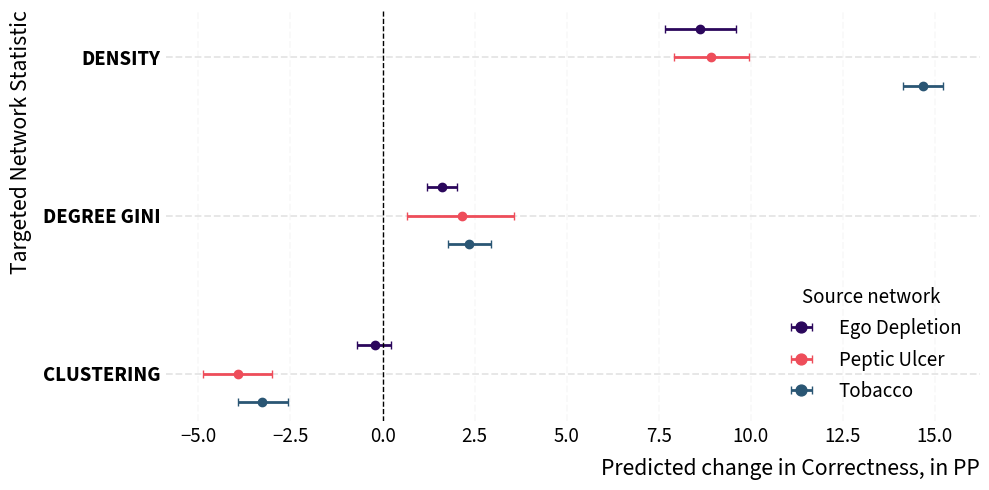

Saved response-scale effect plot to {'pdf': PosixPath('Figures/targeted_stats_v2/targeted_stat_response_scale_forest_plot_q10_q90.pdf'), 'png': PosixPath('Figures/targeted_stats_v2/targeted_stat_response_scale_forest_plot_q10_q90.png')}


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patsy import build_design_matrices
from scipy.special import expit

# ------------------------------------------------------------
# Response-scale contrast plot
# ------------------------------------------------------------
# Main recommended contrast:
#   q10_q90:
#       Move the targeted achieved statistic from its 10th percentile
#       to its 90th percentile within the source-by-target cell.
#
# Optional contrast:
#   relative_delta_from_median:
#       Move the targeted achieved statistic from its median to
#       median * (1 + RELATIVE_DELTA).
#
# Optional contrast:
#   absolute_delta_from_median:
#       Move the targeted achieved statistic from its median to
#       median + ABSOLUTE_DELTAS[target_stat].
#
# The plotted effect is:
#   predicted share correct at high target value
#   minus
#   predicted share correct at low target value
#
# in percentage points.

CONTRAST_MODE = "q10_q90"
RELATIVE_DELTA = 0.10

ABSOLUTE_DELTAS = {
    "density": 0.01,
    "degree_gini": 0.05,
    "clustering": 0.05,
}

N_PARAM_DRAWS = 2000
RNG_SEED = 12345


def get_global_standardization_params(predictor):
    row = global_standardization_df.loc[
        global_standardization_df["predictor"].eq(predictor)
    ]

    if row.empty:
        raise ValueError(f"No global standardization row found for {predictor!r}")

    mean = float(row.iloc[0]["mean"])
    sd = float(row.iloc[0]["sd"])

    if not np.isfinite(sd) or sd <= 0:
        raise ValueError(f"Invalid global standard deviation for {predictor!r}: {sd}")

    return mean, sd


def raw_to_global_z(raw_value, predictor):
    mean, sd = get_global_standardization_params(predictor)
    return (raw_value - mean) / sd


def adjusted_share_to_raw_share(adjusted_p, n_agents=None):
    adjusted_p = np.asarray(adjusted_p, dtype=float)

    if n_agents is None:
        return np.clip(adjusted_p, 0, 1)

    n = np.asarray(n_agents, dtype=float)

    while n.ndim < adjusted_p.ndim:
        n = np.expand_dims(n, axis=-1)

    valid_n = np.isfinite(n) & (n > 1)
    denominator = np.where(valid_n, n - 1, 1.0)
    raw_p = (adjusted_p * n - 0.5) / denominator
    raw_p = np.where(valid_n, raw_p, adjusted_p)

    return np.clip(raw_p, 0, 1)


def sample_params_from_covariance(model, n_draws, rng):
    params = model.params.copy()
    cov = model.cov_params().loc[params.index, params.index].to_numpy(dtype=float)
    cov = 0.5 * (cov + cov.T)

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = np.clip(eigenvalues, 0, None)

    transform = eigenvectors @ np.diag(np.sqrt(eigenvalues))
    standard_normal = rng.normal(size=(n_draws, len(params)))
    draws = standard_normal @ transform.T + params.to_numpy()

    return params.index.tolist(), draws


def choose_contrast_values(data, target_stat, targeted_predictor, contrast_mode):
    values = pd.to_numeric(data[targeted_predictor], errors="coerce").dropna()

    if values.empty:
        raise ValueError(f"No finite values found for {targeted_predictor!r}")

    observed_min = float(values.min())
    observed_max = float(values.max())
    observed_q10 = float(values.quantile(0.10))
    observed_q90 = float(values.quantile(0.90))
    observed_median = float(values.median())

    if contrast_mode == "q10_q90":
        low_value = observed_q10
        high_value = observed_q90
        contrast_label = "10th to 90th percentile"

    elif contrast_mode == "relative_delta_from_median":
        low_value = observed_median
        high_value = observed_median * (1 + RELATIVE_DELTA)
        contrast_label = f"median to median * {1 + RELATIVE_DELTA:.2f}"

    elif contrast_mode == "absolute_delta_from_median":
        delta = ABSOLUTE_DELTAS.get(target_stat)
        if delta is None:
            raise ValueError(f"No absolute delta configured for target stat {target_stat!r}")
        low_value = observed_median
        high_value = observed_median + delta
        contrast_label = f"median to median + {delta:g}"

    else:
        raise ValueError(f"Unknown contrast mode: {contrast_mode!r}")

    within_observed_range = (
        observed_min <= low_value <= observed_max
        and observed_min <= high_value <= observed_max
    )

    within_q10_q90_range = (
        observed_q10 <= low_value <= observed_q90
        and observed_q10 <= high_value <= observed_q90
    )

    return {
        "low_value": float(low_value),
        "high_value": float(high_value),
        "contrast_label": contrast_label,
        "observed_min": observed_min,
        "observed_max": observed_max,
        "observed_q10": observed_q10,
        "observed_q90": observed_q90,
        "observed_median": observed_median,
        "within_observed_range": bool(within_observed_range),
        "within_q10_q90_range": bool(within_q10_q90_range),
    }


def make_contrast_prediction_frames(data, targeted_predictor, low_value, high_value):
    z_col = f"z_{targeted_predictor}"

    low_data = data.copy()
    high_data = data.copy()

    low_data[targeted_predictor] = low_value
    high_data[targeted_predictor] = high_value

    low_data[z_col] = raw_to_global_z(low_value, targeted_predictor)
    high_data[z_col] = raw_to_global_z(high_value, targeted_predictor)

    return low_data, high_data


def predict_average_raw_share(model, data):
    linear_prediction = np.asarray(model.predict(data), dtype=float)
    adjusted_prediction = expit(linear_prediction)

    if agent_count_col in data.columns:
        raw_prediction = adjusted_share_to_raw_share(
            adjusted_prediction,
            data[agent_count_col].to_numpy(),
        )
    else:
        raw_prediction = adjusted_prediction

    return float(np.nanmean(raw_prediction))


def simulate_average_contrast(model, low_data, high_data, n_draws, rng):
    design_info = model.model.data.design_info
    x_low = np.asarray(build_design_matrices([design_info], low_data)[0], dtype=float)
    x_high = np.asarray(build_design_matrices([design_info], high_data)[0], dtype=float)

    param_names, param_draws = sample_params_from_covariance(model, n_draws, rng)

    model_exog_names = list(model.model.exog_names)
    if param_names != model_exog_names:
        param_position = [param_names.index(name) for name in model_exog_names]
        param_draws = param_draws[:, param_position]

    eta_low = x_low @ param_draws.T
    eta_high = x_high @ param_draws.T

    adjusted_low = expit(eta_low)
    adjusted_high = expit(eta_high)

    if agent_count_col in low_data.columns:
        n_agents = low_data[agent_count_col].to_numpy()
        raw_low = adjusted_share_to_raw_share(adjusted_low, n_agents)
        raw_high = adjusted_share_to_raw_share(adjusted_high, n_agents)
    else:
        raw_low = adjusted_low
        raw_high = adjusted_high

    contrast_draws = np.nanmean(raw_high - raw_low, axis=0)
    low_draws = np.nanmean(raw_low, axis=0)
    high_draws = np.nanmean(raw_high, axis=0)

    return {
        "delta_draws": contrast_draws,
        "low_share_draws": low_draws,
        "high_share_draws": high_draws,
    }


def summarize_draws(draws):
    draws = np.asarray(draws, dtype=float)
    draws = draws[np.isfinite(draws)]

    if draws.size == 0:
        return {
            "mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    return {
        "mean": float(np.mean(draws)),
        "ci_low": float(np.quantile(draws, 0.025)),
        "ci_high": float(np.quantile(draws, 0.975)),
    }


rng = np.random.default_rng(RNG_SEED)
response_effect_rows = []

for _, coef_row in coef_df.iterrows():
    source_id = str(coef_row["source_id"])
    target_stat = str(coef_row["target_stat"])
    name = f"{source_id} | {target_stat}"

    if name not in models or name not in model_data:
        continue

    model = models[name]
    data = model_data[name].copy()
    targeted_predictor = target_predictor_map[target_stat]

    contrast = choose_contrast_values(
        data=data,
        target_stat=target_stat,
        targeted_predictor=targeted_predictor,
        contrast_mode=CONTRAST_MODE,
    )

    low_data, high_data = make_contrast_prediction_frames(
        data=data,
        targeted_predictor=targeted_predictor,
        low_value=contrast["low_value"],
        high_value=contrast["high_value"],
    )

    low_share = predict_average_raw_share(model, low_data)
    high_share = predict_average_raw_share(model, high_data)
    delta_share = high_share - low_share

    draws = simulate_average_contrast(
        model=model,
        low_data=low_data,
        high_data=high_data,
        n_draws=N_PARAM_DRAWS,
        rng=rng,
    )

    delta_summary = summarize_draws(draws["delta_draws"])
    low_summary = summarize_draws(draws["low_share_draws"])
    high_summary = summarize_draws(draws["high_share_draws"])

    if np.isfinite(low_share) and low_share > 0:
        relative_percent_change = 100 * (high_share / low_share - 1)
    else:
        relative_percent_change = np.nan

    response_effect_rows.append({
        "source_id": source_id,
        "source_label": source_label(source_id),
        "target_stat": target_stat,
        "target_label": label_map.get(target_stat, target_stat),
        "targeted_predictor": targeted_predictor,
        "contrast_mode": CONTRAST_MODE,
        "contrast_label": contrast["contrast_label"],
        "low_target_value": contrast["low_value"],
        "high_target_value": contrast["high_value"],
        "target_difference_raw_units": contrast["high_value"] - contrast["low_value"],
        "observed_min": contrast["observed_min"],
        "observed_max": contrast["observed_max"],
        "observed_q10": contrast["observed_q10"],
        "observed_q90": contrast["observed_q90"],
        "observed_median": contrast["observed_median"],
        "within_observed_range": contrast["within_observed_range"],
        "within_q10_q90_range": contrast["within_q10_q90_range"],
        "predicted_low_share_correct": low_share,
        "predicted_high_share_correct": high_share,
        "delta_share_correct": delta_share,
        "delta_percentage_points": 100 * delta_share,
        "delta_percentage_points_ci_low": 100 * delta_summary["ci_low"],
        "delta_percentage_points_ci_high": 100 * delta_summary["ci_high"],
        "predicted_low_share_correct_ci_low": low_summary["ci_low"],
        "predicted_low_share_correct_ci_high": low_summary["ci_high"],
        "predicted_high_share_correct_ci_low": high_summary["ci_low"],
        "predicted_high_share_correct_ci_high": high_summary["ci_high"],
        "relative_percent_change": relative_percent_change,
        "n_obs": int(model.nobs),
    })

response_effect_df = pd.DataFrame(response_effect_rows)

response_effect_df = response_effect_df.sort_values(
    ["target_stat", "source_id"],
    key=lambda s: s.map(target_sort_key) if s.name == "target_stat" else s,
).reset_index(drop=True)

response_effect_path = figures_dir / f"targeted_stat_response_scale_effects_{CONTRAST_MODE}.csv"
response_effect_df.to_csv(response_effect_path, index=False)

display_columns = [
    "source_id",
    "target_stat",
    "contrast_label",
    "low_target_value",
    "high_target_value",
    "target_difference_raw_units",
    "predicted_low_share_correct",
    "predicted_high_share_correct",
    "delta_percentage_points",
    "delta_percentage_points_ci_low",
    "delta_percentage_points_ci_high",
    "relative_percent_change",
    "within_observed_range",
    "within_q10_q90_range",
    "n_obs",
]

display(response_effect_df[display_columns])
print(f"Saved response-scale effect table to {response_effect_path}")


# ------------------------------------------------------------
# Plot response-scale effects
# ------------------------------------------------------------

source_order = sorted(response_effect_df["source_id"].unique())
source_colors = {source_id: source_color(source_id) for source_id in source_order}
y_base = {target_stat: idx for idx, target_stat in enumerate(target_stat_order)}
offsets = dict(zip(source_order, np.linspace(-0.18, 0.18, len(source_order))))

fig, ax = plt.subplots(figsize=(10, 5))

for source_id in source_order:
    subset = response_effect_df[response_effect_df["source_id"] == source_id].copy()
    y = [y_base[target_stat] + offsets[source_id] for target_stat in subset["target_stat"]]

    x = subset["delta_percentage_points"].to_numpy()
    xerr = np.vstack([
        x - subset["delta_percentage_points_ci_low"].to_numpy(),
        subset["delta_percentage_points_ci_high"].to_numpy() - x,
    ])

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        fmt="o",
        color=source_colors[source_id],
        ecolor=source_colors[source_id],
        elinewidth=2,
        capsize=3,
        markersize=6,
        label=source_label(source_id),
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks([y_base[target_stat] for target_stat in target_stat_order])
ax.set_yticklabels([label_map.get(target_stat, target_stat).upper() for target_stat in target_stat_order], fontweight="bold")
ax.invert_yaxis()
ax.set_xlabel("Predicted change in Correctness, in PP",fontweight="regular")
ax.set_ylabel("Targeted Network Statistic",fontweight="regular")
ax.legend(title="Source network", frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)

# title = f"Response-scale effect of targeted statistic: {response_effect_df['contrast_label'].iloc[0]}"
# ax.set_title(title)

plt.tight_layout()
response_plot_path = figures_dir / f"targeted_stat_response_scale_forest_plot_{CONTRAST_MODE}.pdf"
response_plot_paths = save_figure_with_png(fig, response_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved response-scale effect plot to {response_plot_paths}")